In [0]:
%%sh
# IMPORTANTE: ESTE COMANDO SÓ E EXECUTADO EM DESENVOLVIMENTO EM PRODUÇÃO SERÁ VIA JOB E A CONFIGURAÇÃO ESTÃO NO ARQUIVO resources/job.yml ou outros arquivo que será executado em produção
uv sync

Resolved 122 packages in 8ms
Audited 96 packages in 4ms


In [0]:
# ==============================================================================
# notebooks/ml/02_vies_threshold_roi.py
# Responde Q1-Q4 do README.md — SHAP, threshold sob custo assimétrico, viés
# por idade/renda e impacto financeiro. Lógica em
# src/models/bias_roi_validation.py; este notebook só orquestra e plota.
#
# Complementar a este: notebooks/ml/01_hipoteses_h1_h4.py (hipóteses H1-H4).
# ==============================================================================

In [0]:
dbutils.widgets.text("catalog", "credito_dev")
catalog = dbutils.widgets.get("catalog")

MODEL_NAME = "credito_risco_xgb"
MODEL_ALIAS = "champion"

In [0]:
import sys
import os


def _find_repo_root(start: str) -> str:
    path = start
    for _ in range(6):
        if os.path.isdir(os.path.join(path, "src")):
            return path
        parent = os.path.dirname(path)
        if parent == path:
            break
        path = parent
    raise RuntimeError(f"Não encontrei a pasta 'src' subindo a partir de {start}.")


repo_root = _find_repo_root(os.getcwd())
if repo_root not in sys.path:
    sys.path.append(repo_root)

from src.models import bias_roi_validation as brv
from src.models.hypothesis_validation import load_gold_training_data
import matplotlib.pyplot as plt
import shap

## 1. Dados e modelo

In [0]:
df = load_gold_training_data(spark, catalog=catalog)
X_train, X_test, y_train, y_test = brv.prepare_train_test(df)

model = brv.load_or_train_model(
    spark, catalog=catalog, schema="gold", model_name=MODEL_NAME, model_alias=MODEL_ALIAS,
    X_train=X_train, y_train=y_train, X_test=X_test, y_test=y_test,
)
y_proba_test = model.predict_proba(X_test)[:, 1]

{"ts": "2026-09-21 18:27:03.677", "level": "WARNING", "logger": "pyspark.sql.connect.logging", "msg": "Effective usage policy for this session is cct.Chpub3RlYm9va3MvMjc1MDg2NTk1NDg4MjkxMBABIAEyJDAxYTBjNTM3LWU3NTYtNzU4Ni04NDFhLTdhNjM0NmVlMGFjZTokMTFmMzY2NTItNzM5MS0zNjU4LTgyYjEtNjlkMmQ4Y2JhMGIzSgwIwu3F1QYQgNv7uQFQAVgBYAFoyc/zr+PEow0=.", "context": {}}
{"ts": "2026-09-21 18:27:03.677", "level": "WARNING", "logger": "pyspark.sql.connect.logging", "msg": "Effective usage policy for this session is cct.Chpub3RlYm9va3MvMjc1MDg2NTk1NDg4MjkxMBABIAEyJDAxYTBjNTM3LWU3NTYtNzU4Ni04NDFhLTdhNjM0NmVlMGFjZTokMTFmMzY2NTItNzM5MS0zNjU4LTgyYjEtNjlkMmQ4Y2JhMGIzSgwIwu3F1QYQgNv7uQFQAVgBYAFoyc/zr+PEow0=.", "context": {}}
{"ts": "2026-09-21 18:27:03.677", "level": "WARNING", "logger": "pyspark.sql.connect.logging", "msg": "Effective usage policy for this session is cct.Chpub3RlYm9va3MvMjc1MDg2NTk1NDg4MjkxMBABIAEyJDAxYTBjNTM3LWU3NTYtNzU4Ni04NDFhLTdhNjM0NmVlMGFjZTokMTFmMzY2NTItNzM5MS0zNjU4LTgyYjEtNjlkMmQ4Y2JhMGIz

Modelo carregado do Registry: models:/credito_dev.gold.credito_risco_xgb@champion


## Q1 — Importância de variáveis via SHAP

                  feature  mean_abs_shap  rank
    revolving_utilization       0.721352     1
 total_delinquency_events       0.717694     2
                      age       0.242924     3
    num_open_credit_lines       0.189288     4
           monthly_income       0.158701     5
               debt_ratio       0.154459     6
   num_times_90_days_late       0.131428     7
    num_real_estate_loans       0.115524     8
num_times_60_89_days_late       0.063668     9
num_times_30_59_days_late       0.042003    10
           num_dependents       0.036552    11


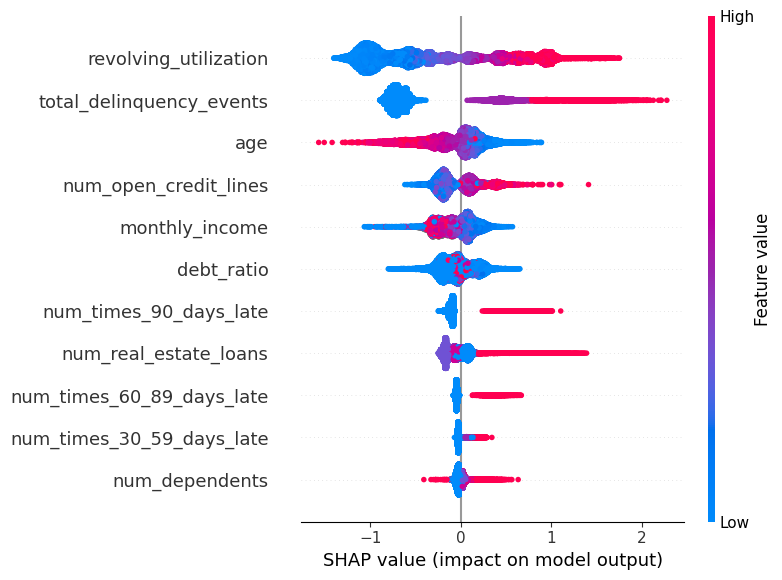

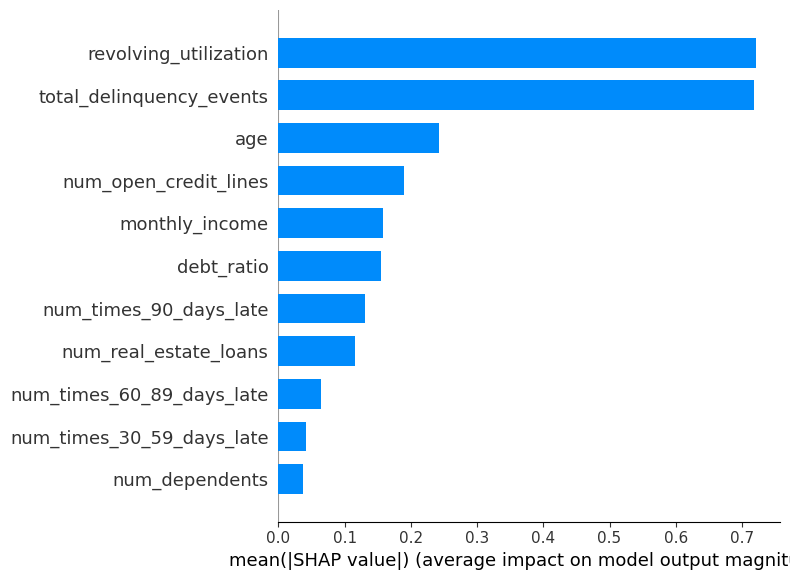


H1 (atrasos específicos no top-5): CONTRARIADA
H2 (revolving_utilization/monthly_income no top-5): CONFIRMADA


In [0]:
ranking_shap, shap_values = brv.compute_shap_ranking(model, X_test)
print(ranking_shap.to_string(index=False))

shap.summary_plot(shap_values, X_test, show=False)
plt.tight_layout()
plt.show()

shap.summary_plot(shap_values, X_test, plot_type="bar", show=False)
plt.tight_layout()
plt.show()

top_features = set(ranking_shap.head(5)["feature"])
status_h1 = brv.check_top_n(brv.H1_FEATURES, top_features)
status_h2 = brv.check_top_n(brv.H2_FEATURES, top_features)
print(f"\nH1 (atrasos específicos no top-5): {status_h1}")
print(f"H2 (revolving_utilization/monthly_income no top-5): {status_h2}")

## Q2 — Threshold ótimo sob custo assimétrico
Custos vêm de `src/config/business_params.py` — mesma fonte usada em
H4 (`01_hipoteses_h1_h4.py`). O número final ainda pode diferir de H4
porque usa um threshold diferente (aqui, o que minimiza custo; em H4,
o menor que respeita o piso de aprovação) — isso é intencional.

Threshold ótimo: 0.57
Custo no threshold ótimo: R$ 18,838,500.00
Custo no threshold 0.50: R$ 18,970,500.00
Economia: R$ 132,000.00


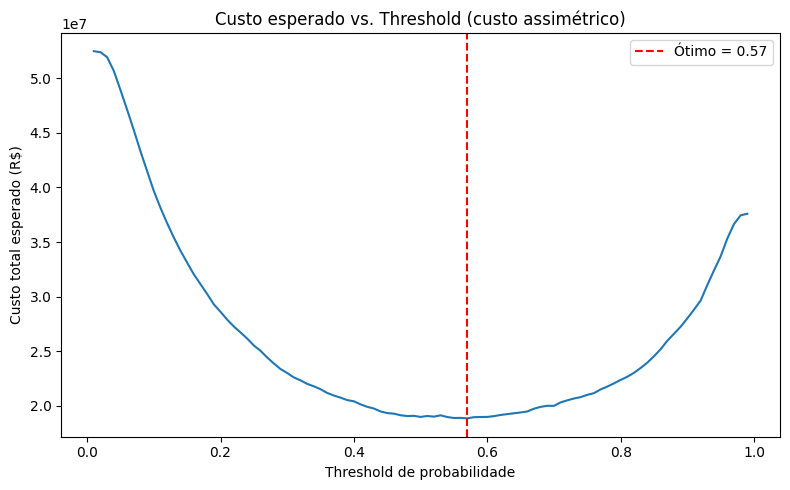

In [0]:
threshold_result = brv.optimize_threshold_asymmetric(y_test, y_proba_test)
print(f"Threshold ótimo: {threshold_result['threshold_otimo']:.2f}")
print(f"Custo no threshold ótimo: R$ {threshold_result['custo_threshold_otimo']:,.2f}")
print(f"Custo no threshold 0.50: R$ {threshold_result['custo_threshold_050']:,.2f}")
print(f"Economia: R$ {threshold_result['economia']:,.2f}")

df_custos = threshold_result["df_custos"]
plt.figure(figsize=(8, 5))
plt.plot(df_custos["threshold"], df_custos["custo_total"])
plt.axvline(threshold_result["threshold_otimo"], color="red", linestyle="--",
            label=f"Ótimo = {threshold_result['threshold_otimo']:.2f}")
plt.xlabel("Threshold de probabilidade")
plt.ylabel("Custo total esperado (R$)")
plt.title("Custo esperado vs. Threshold (custo assimétrico)")
plt.legend()
plt.tight_layout()
plt.show()

## Q3 — Estabilidade / viés por faixa de idade e renda

In [0]:
bias_result = brv.bias_analysis(X_test, y_test, y_proba_test, threshold_result["threshold_otimo"])
if bias_result["aviso_renda"]:
    print(f"[AVISO] {bias_result['aviso_renda']}")

print("\n=== Performance por faixa etária ===")
print(bias_result["tabela_idade"].to_string(index=False))
print("\n=== Performance por faixa de renda ===")
print(bias_result["tabela_renda"].to_string(index=False))

if bias_result["alertas"]:
    print("\n[ALERTA] Grupos com FPR/FNR desproporcional (> média + 1 desvio-padrão):")
    for alerta in bias_result["alertas"]:
        print(f"  {alerta}")

[AVISO] faixa_renda: apenas 4 faixas distintas geradas (esperado 5) — dados de 'monthly_income' concentrados/nulos.

=== Performance por faixa etária ===
grupo     n  acuracia  fpr_bons_negados  fnr_maus_aprovados
18-30  2676  0.718236          0.296689            0.171875
31-40  5985  0.760234          0.239756            0.239859
41-50  8745  0.806061          0.186727            0.271505
51-60  8931  0.850969          0.135842            0.345811
  60+ 11159  0.937181          0.050715            0.480892

=== Performance por faixa de renda ===
              grupo     n  acuracia  fpr_bons_negados  fnr_maus_aprovados
   (-0.001, 3451.6] 15000  0.831400          0.162088            0.251371
   (3451.6, 5416.0]  7593  0.822073          0.171090            0.259829
   (5416.0, 8300.0]  7438  0.851573          0.136253            0.337029
(8300.0, 1072500.0]  7469  0.875084          0.109122            0.422872

[ALERTA] Grupos com FPR/FNR desproporcional (> média + 1 desvio-padrão):
  

## Q4 — Impacto financeiro estimado

In [0]:
financial_result = brv.financial_impact(bias_result["df_val"])
print(f"Operações analisadas: {financial_result['n_operacoes']}")
print(f"Taxa de inadimplência sem modelo: {financial_result['taxa_sem_modelo']:.2%} "
      f"-> Perda estimada: R$ {financial_result['perda_sem_modelo']:,.2f}")
print(f"Taxa de inadimplência com modelo: {financial_result['taxa_com_modelo']:.2%} "
      f"-> Perda estimada: R$ {financial_result['perda_com_modelo']:,.2f}")
print(f"Redução bruta de inadimplência: R$ {financial_result['reducao_bruta']:,.2f}")
print(f"Custo de oportunidade (bons pagadores negados): R$ {financial_result['custo_oportunidade']:,.2f}")
print(f"Impacto financeiro líquido estimado: R$ {financial_result['impacto_liquido']:,.2f}")

Operações analisadas: 37500
Taxa de inadimplência sem modelo: 6.68% -> Perda estimada: R$ 30,072,000.00
Taxa de inadimplência com modelo: 2.42% -> Perda estimada: R$ 8,856,000.00
Redução bruta de inadimplência: R$ 21,216,000.00
Custo de oportunidade (bons pagadores negados): R$ 7,768,500.00
Impacto financeiro líquido estimado: R$ 13,447,500.00


## Registro no MLflow

In [0]:
brv.log_validation_to_mlflow(threshold_result, financial_result, ranking_shap, bias_result, status_h1, status_h2)


Validação concluída e registrada no MLflow.
